In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("gecco_complete_data.csv")
df.head()

,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
0,2016-09-07 00:00:00,7.7,0.17,8.39,752.0,211.0,0.026,0.110,1668.0,829.0,False
1,2016-09-07 00:01:00,7.7,0.17,8.39,752.0,211.0,0.026,0.111,1662.0,826.0,False
2,2016-09-07 00:02:00,7.7,0.17,8.39,753.0,211.0,0.026,0.113,1689.0,818.0,False
3,2016-09-07 00:03:00,7.7,0.17,8.39,752.0,211.0,0.026,0.113,1645.0,826.0,False
4,2016-09-07 00:04:00,7.7,0.17,8.39,752.0,211.0,0.026,0.114,1659.0,832.0,False


In [30]:
# for col in df.select_dtypes(include='number').columns:
#     plt.figure(figsize=(16, 8))
#     plt.plot(df[col].values)
#     for j in df[df['EVENT'] == 1].index:
#         plt.axvline(x=j, color='r', linestyle='-', alpha=0.1)
#     plt.title(col)
#     plt.show()
    

In [31]:
# ensure Time is datetime before time-based grouping
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

group_freq = '10min'  # Grouping frequency (5 minutes)

df_grouped = (
    df.dropna(subset=['Time'])
      .set_index('Time')
      .groupby(pd.Grouper(freq=group_freq))
      .mean(numeric_only=True)
 )

df_grouped['EVENT'] = (
    df.dropna(subset=['Time'])
      .set_index('Time')
      .groupby(pd.Grouper(freq=group_freq))['EVENT']
      .max()
 )

df_grouped.head()

,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
Time,,,,,,,,,,
2016-09-07 00:00:00,7.7,0.17,8.391,751.8,211.0,0.0263,0.1129,1685.2,827.9,False
2016-09-07 00:10:00,7.7,0.17,8.381,752.1,211.0,0.0262,0.1136,1676.4,825.2,False
2016-09-07 00:20:00,7.7,0.17,8.367,752.4,211.0,0.0267,0.1130,1649.3,830.1,False
2016-09-07 00:30:00,7.7,0.17,8.371,751.7,211.0,0.0278,0.1119,1635.3,828.8,False
2016-09-07 00:40:00,7.7,0.17,8.382,751.3,211.0,0.0279,0.1118,1583.6,827.4,False


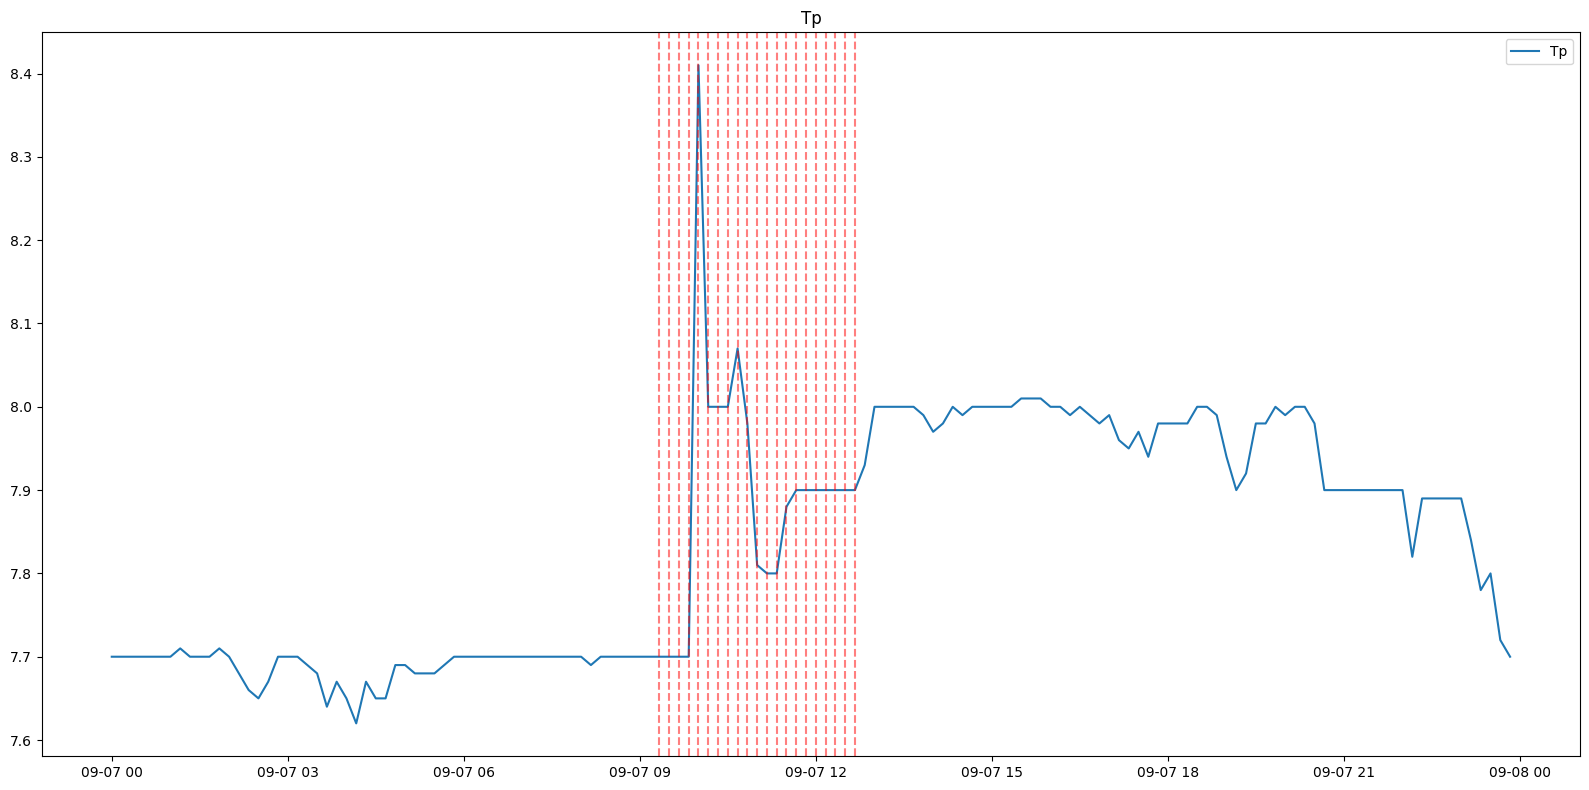

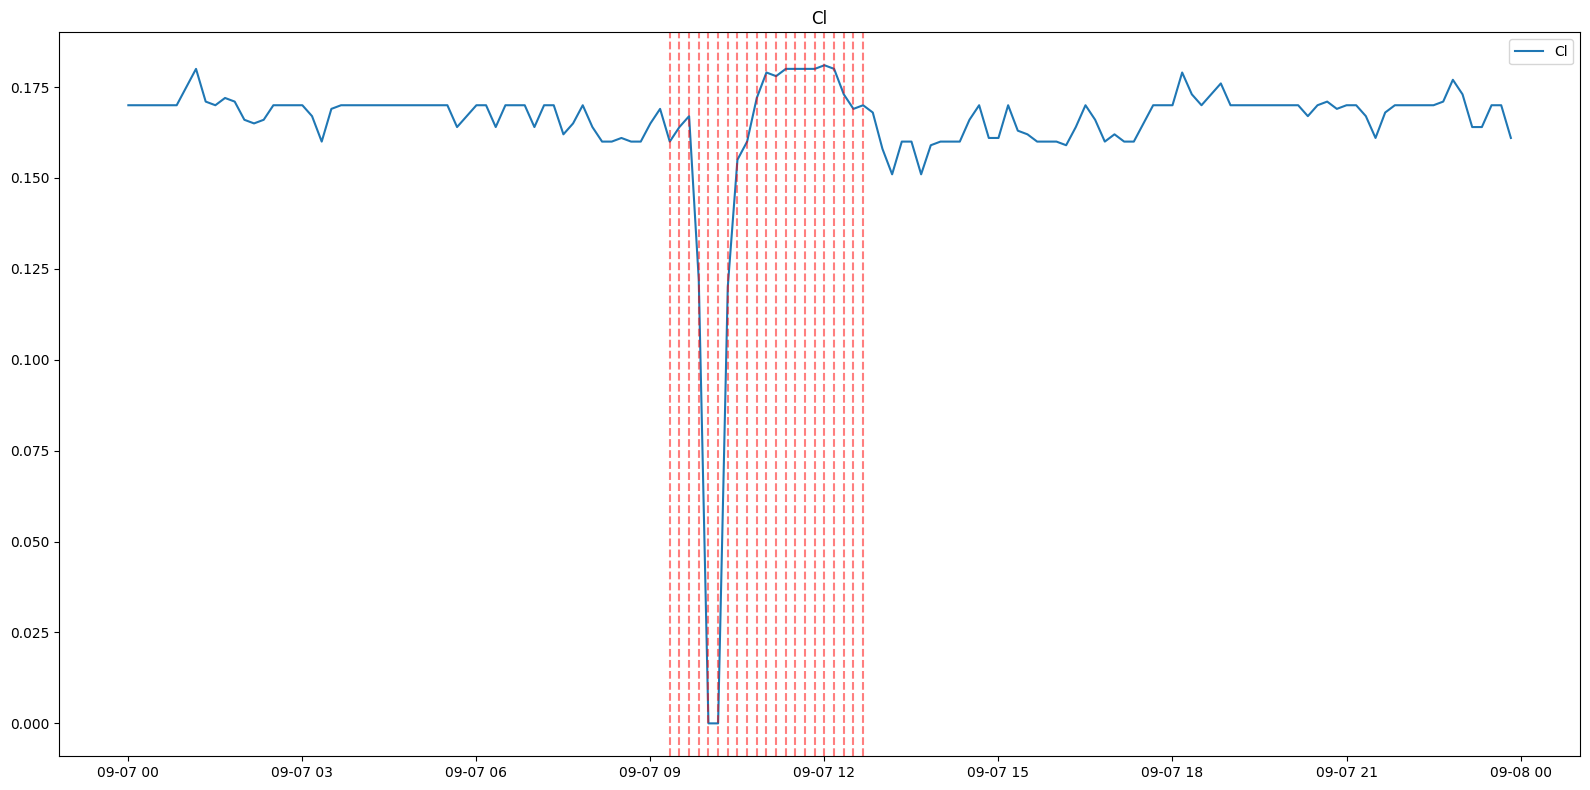

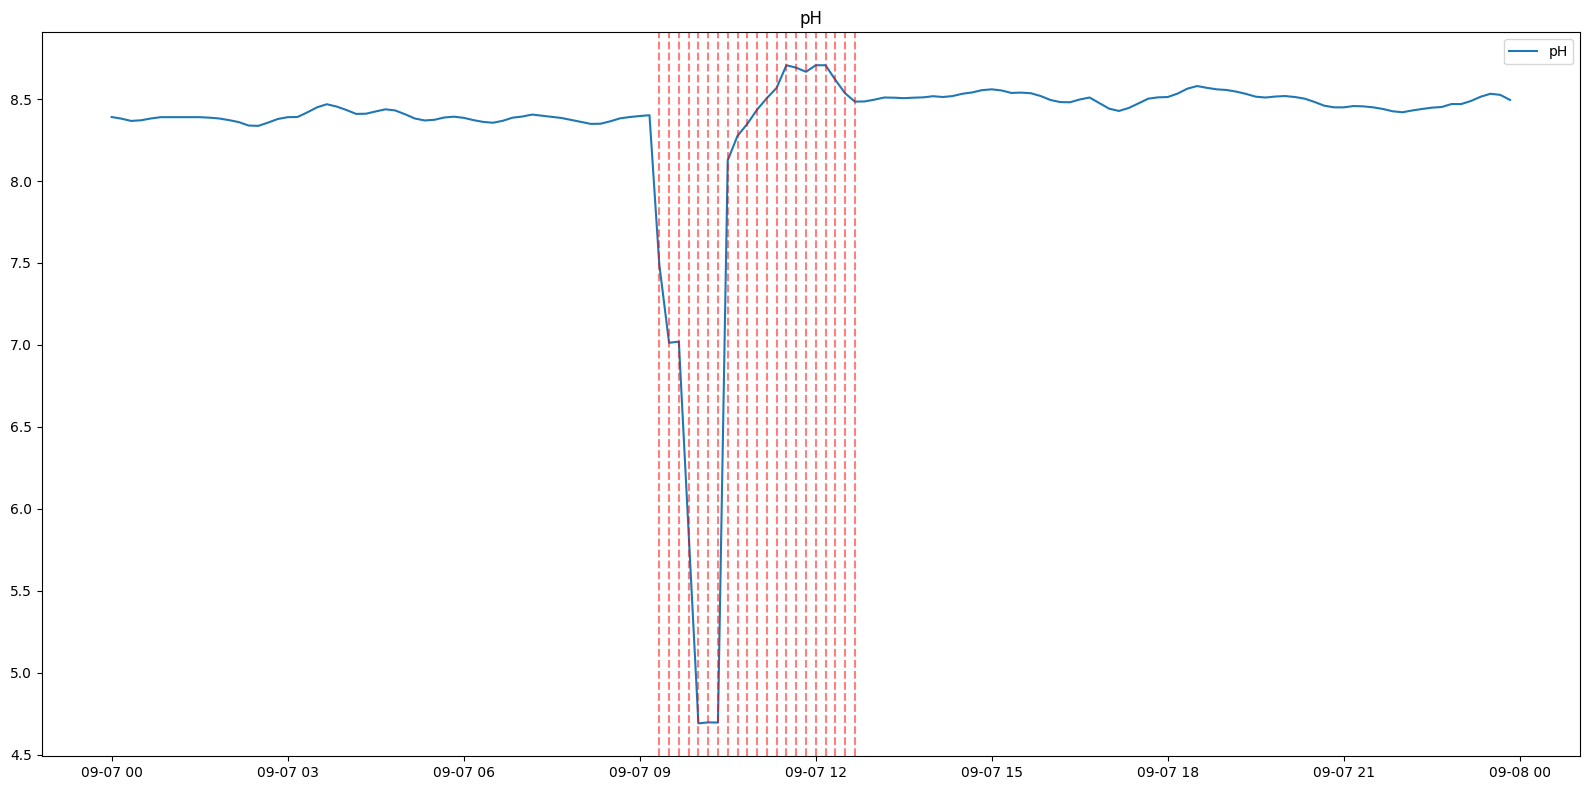

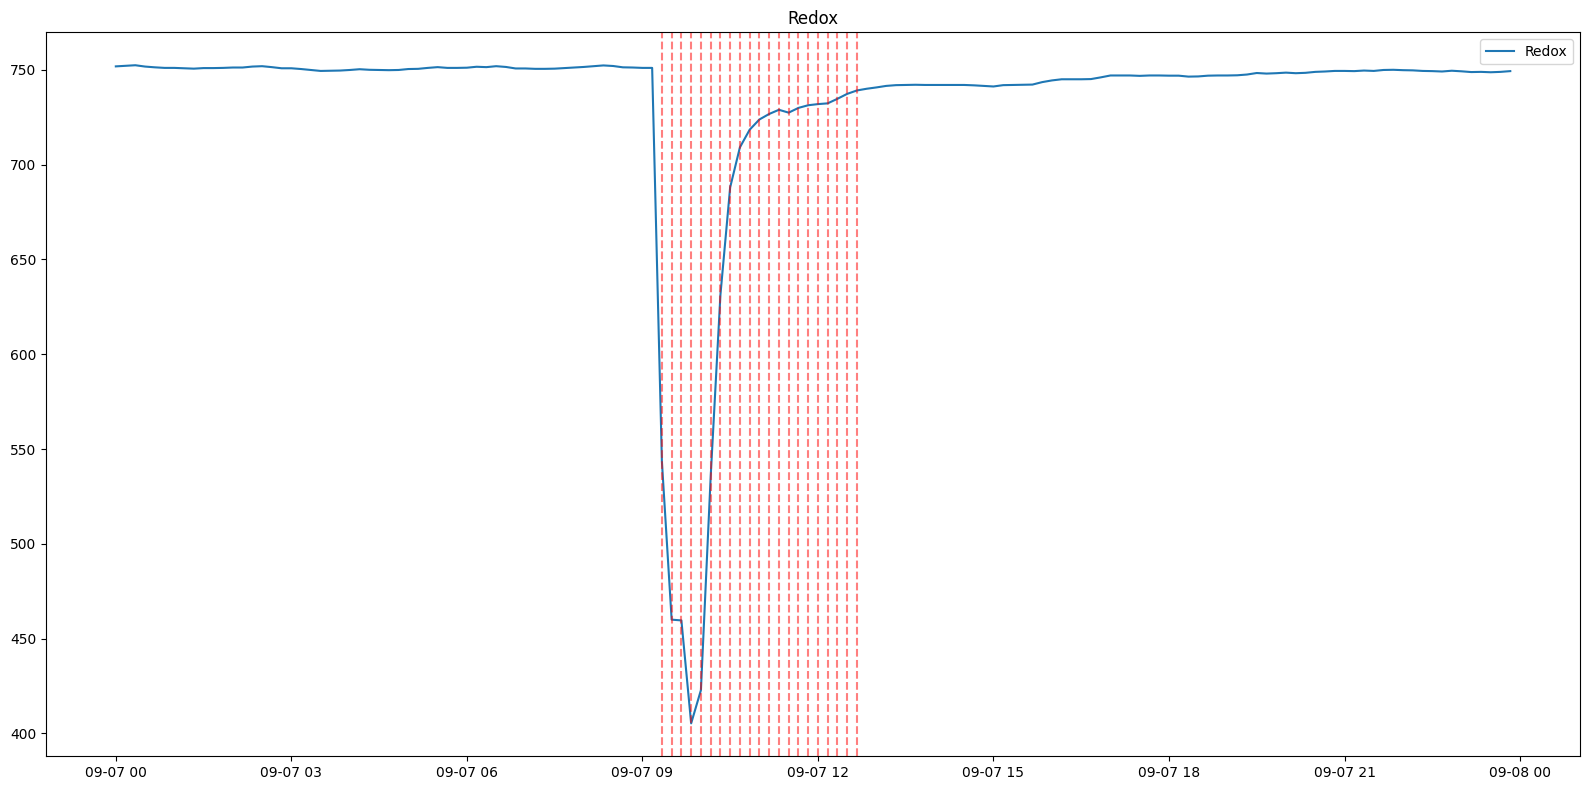

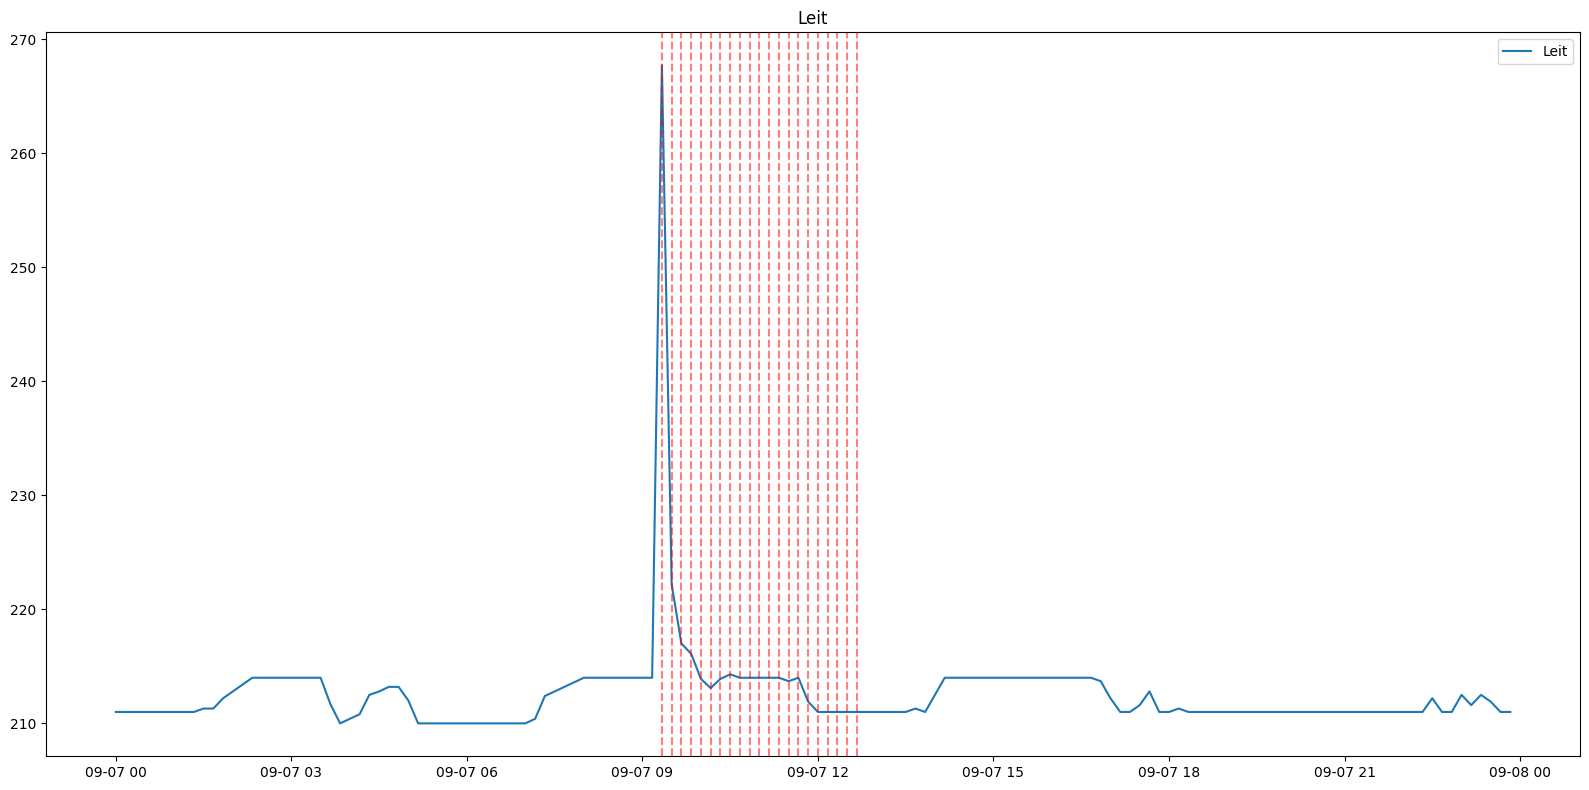

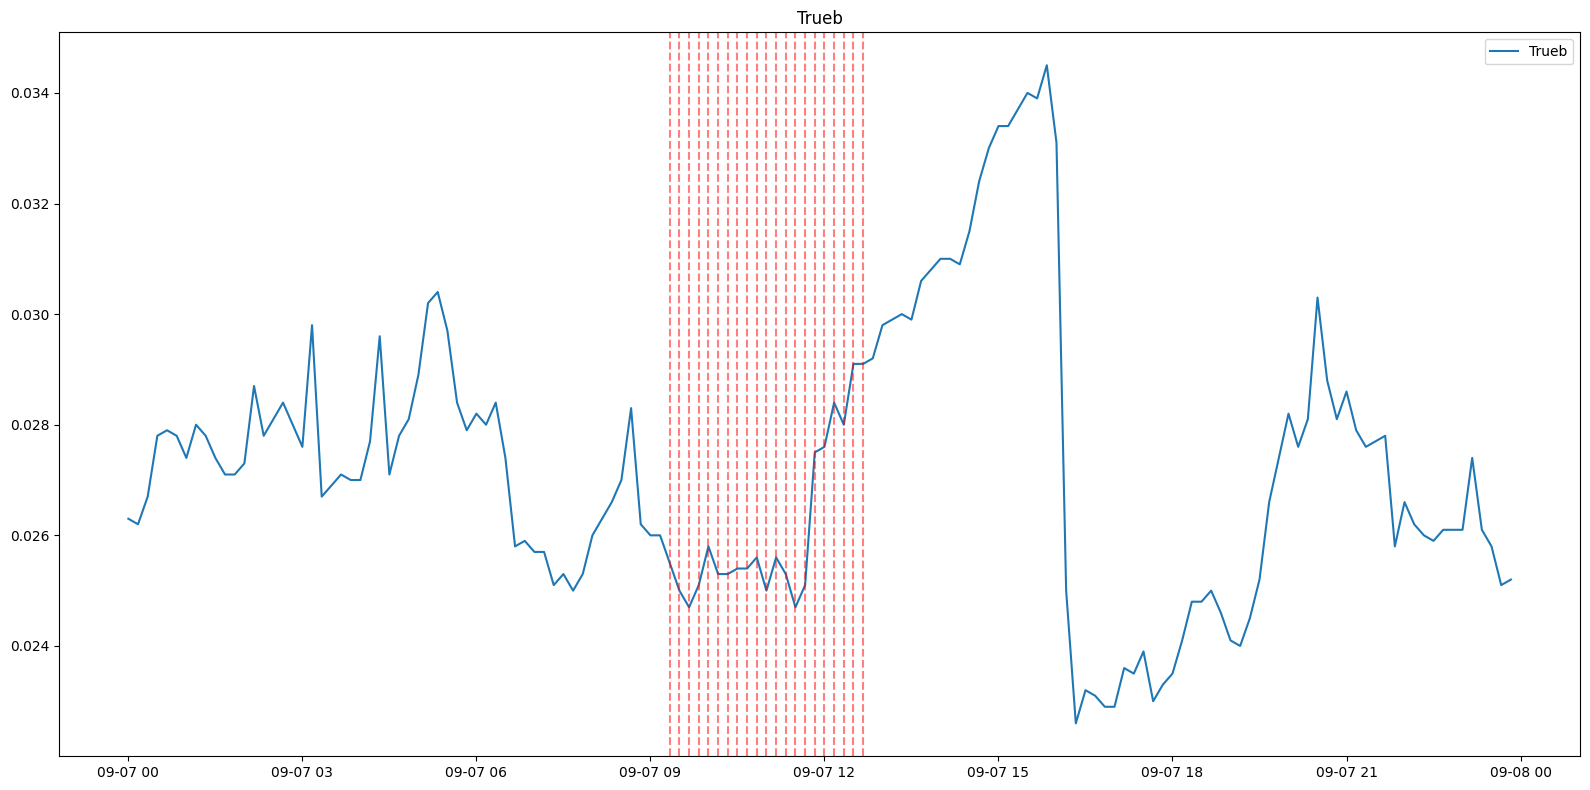

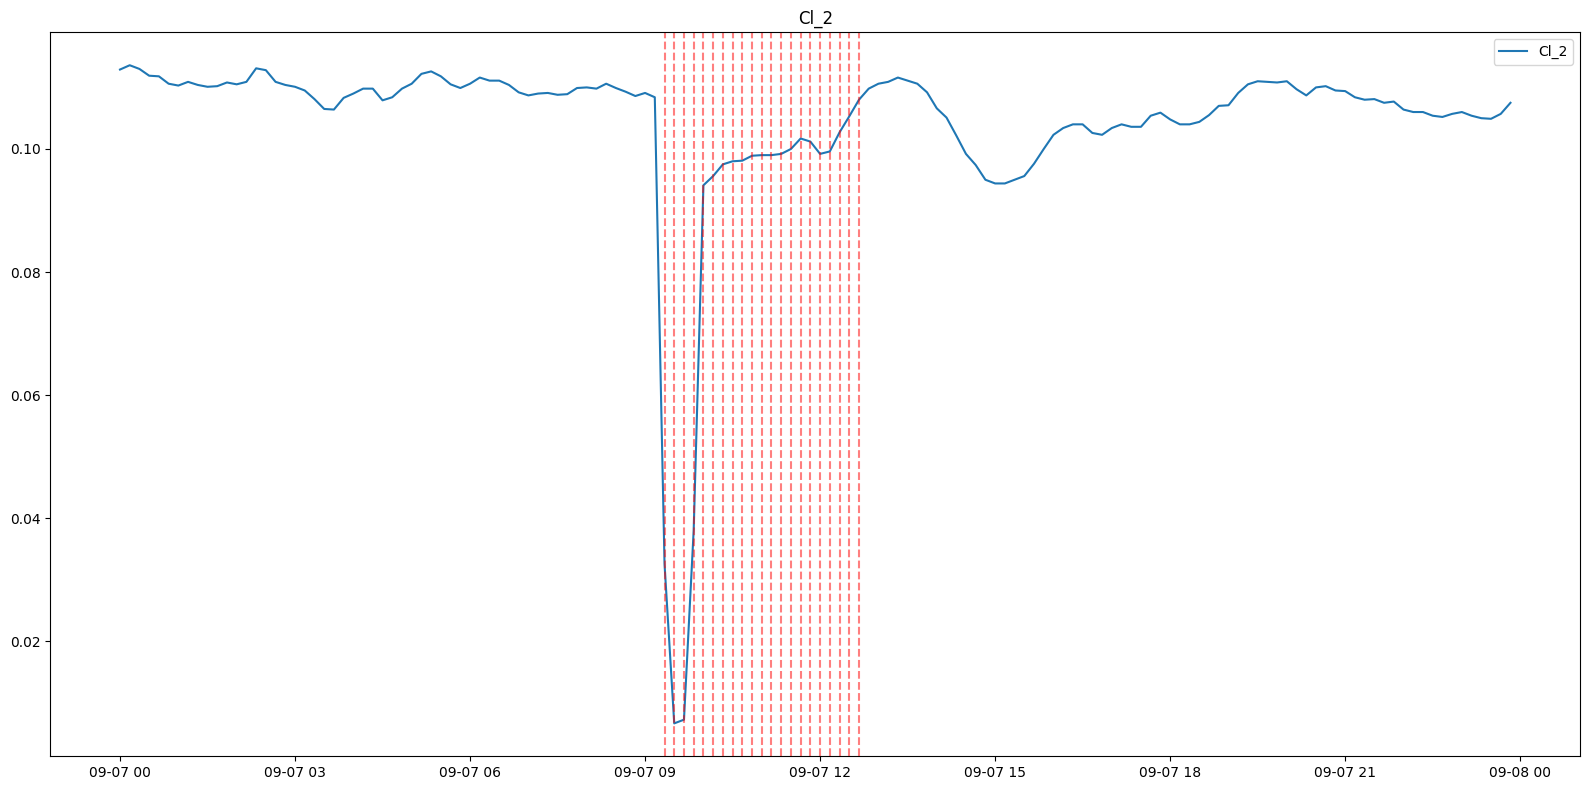

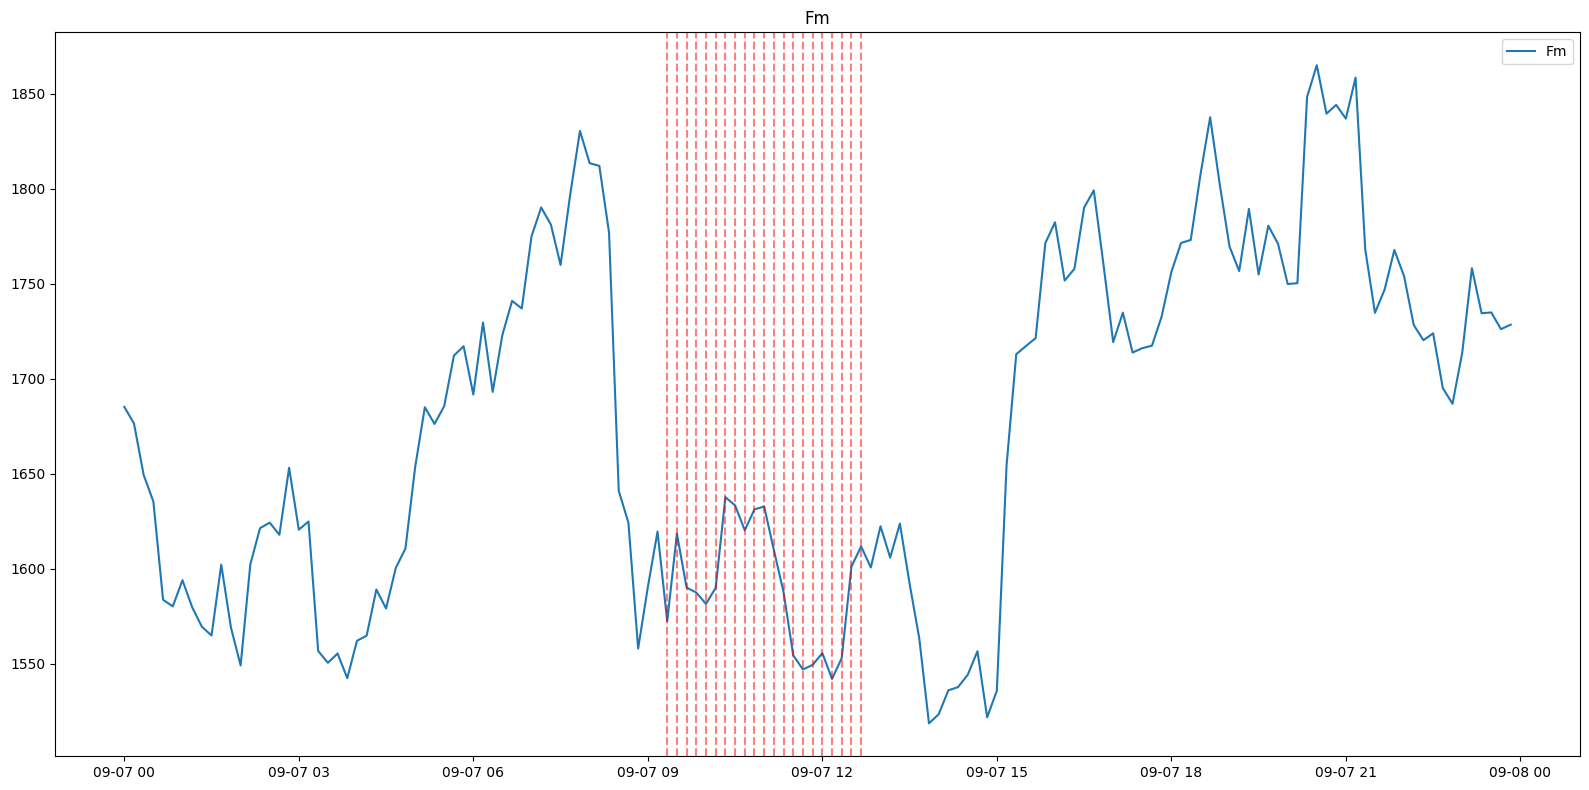

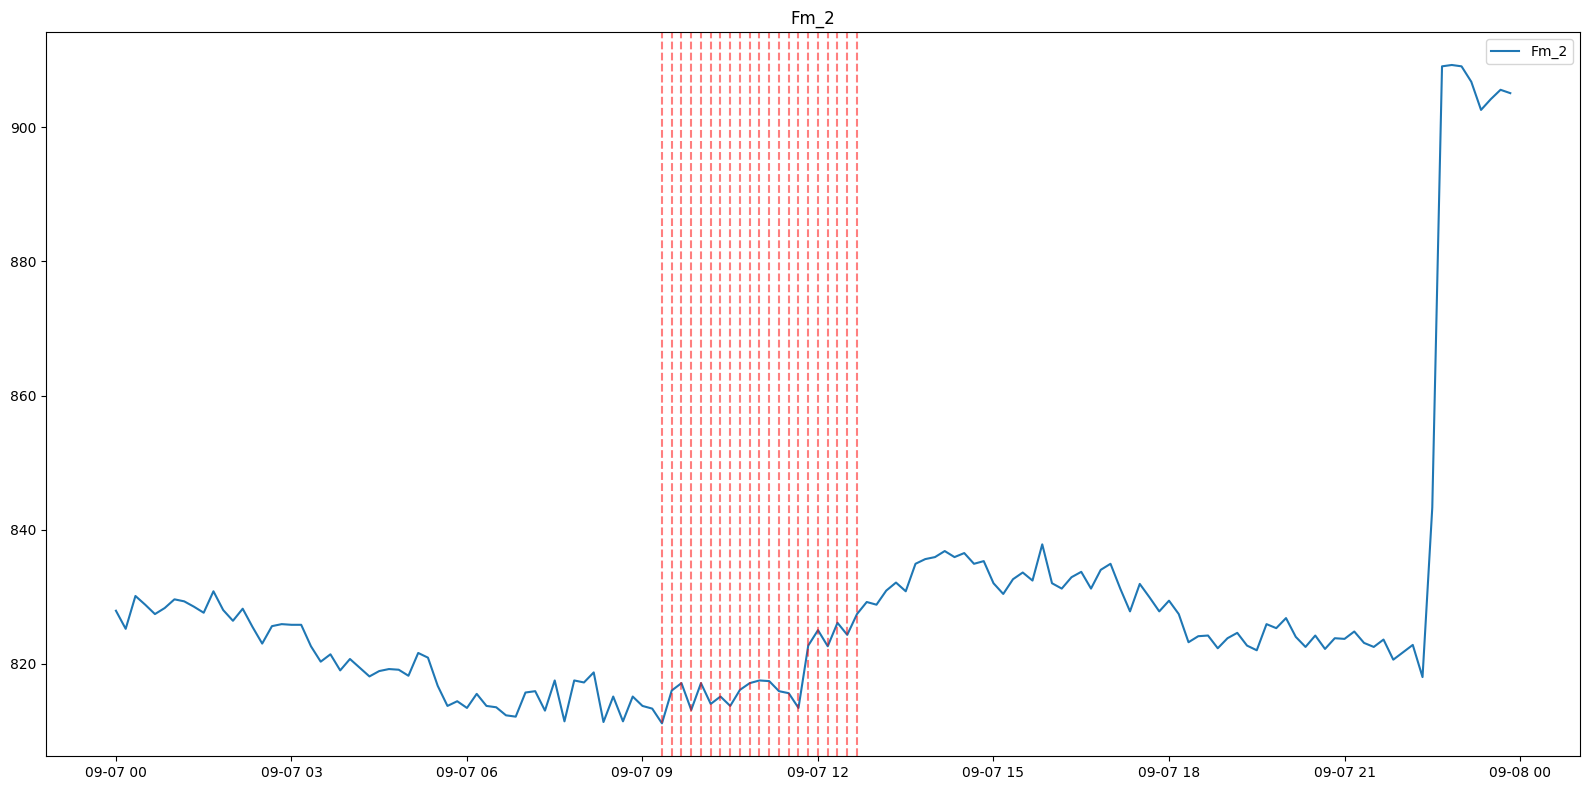

In [32]:
anomaly_times = df_grouped.index[df_grouped['EVENT'] == 1]

for col in df_grouped.select_dtypes(include='number').columns:
    if col == 'EVENT':
        continue

    plt.figure(figsize=(16, 8))
    plt.plot(df_grouped.index, df_grouped[col].values, label=col)
    for j in anomaly_times:
        plt.axvline(x=j, color='r', linestyle='--', alpha=0.5)
    plt.title(col)
    plt.legend()
    plt.tight_layout()
    plt.show()